# **Movie Dataset Python Assignment**


### **Question 1**
Dataset (`movie.csv`) ko pandas mein load karein aur uske pehle 5 rows display karein.

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('movie.csv')

df.head()

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,Director,Star1,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142 min,Drama,9.3,80.0,Frank Darabont,Tim Robbins,2343110,28341469.0
1,The Godfather,1972,A,175 min,"Crime, Drama",9.2,100.0,Francis Ford Coppola,Marlon Brando,1620367,134966411.0
2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,84.0,Christopher Nolan,Christian Bale,2303232,534858444.0
3,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,90.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0
4,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,96.0,Sidney Lumet,Henry Fonda,689845,4360000.0


### **Question 2**
Dataset ka total shape (rows aur columns count) check karke print karein.

In [22]:
print("Shape of dataset (rows, columns):", df.shape)

Shape of dataset (rows, columns): (1000, 11)


### **Question 3**
Check karein ki kis kis column mein missing values (null values) hain aur unka exact count kya hai.

In [26]:
print(df.isnull().sum())

Series_Title       0
Released_Year      0
Certificate      101
Runtime            0
Genre              0
IMDB_Rating        0
Meta_score       157
Director           0
Star1              0
No_of_Votes        0
Gross            169
dtype: int64


### **Question 4**
Which movies were released after the year 2000? (Year 2000 ke baad release hone wali movies filter karein).

In [38]:
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

after_2000 = df[df['Released_Year'] > 2000]
after_2000[['Series_Title', 'Released_Year']]

,Series_Title,Released_Year
2,The Dark Knight,2008.0
5,The Lord of the Rings: The Return of the King,2003.0
8,Inception,2010.0
10,The Lord of the Rings: The Fellowship of the Ring,2001.0
13,The Lord of the Rings: The Two Towers,2002.0
...,...,...
947,Harry Potter and the Sorcerer's Stone,2001.0
948,The Others,2001.0
949,Blow,2001.0
950,Enemy at the Gates,2001.0


### **Question 5**
Which movies have an IMDB rating greater than 9? (9 se zyada IMDB rating wali movies display karein).

In [46]:
high_rated = df[df['IMDB_Rating'] > 9]
high_rated[['Series_Title', 'IMDB_Rating']]

,Series_Title,IMDB_Rating
0,The Shawshank Redemption,9.3
1,The Godfather,9.2


### **Question 6**
How many movies are there for each genre? (Har genre ki total kitni movies hain, count nikalye).

In [52]:
df['Genre'].value_counts()

Genre
Drama                        85
Drama, Romance               37
Comedy, Drama                35
Comedy, Drama, Romance       31
Action, Crime, Drama         30
                             ..
Adventure, Thriller           1
Animation, Action, Sci-Fi     1
Action, Crime, Comedy         1
Animation, Crime, Mystery     1
Adventure, Comedy, War        1
Name: count, Length: 202, dtype: int64

### **Question 7**
Which movies were directed by Christopher Nolan? (Christopher Nolan ki directed saari movies nikalye).

In [64]:
nolan_movies = df[df['Director'] == 'Christopher Nolan']
nolan_movies[['Series_Title', 'Released_Year', 'IMDB_Rating']]

,Series_Title,Released_Year,IMDB_Rating
2,The Dark Knight,2008.0,9.0
8,Inception,2010.0,8.8
21,Interstellar,2014.0,8.6
36,The Prestige,2006.0,8.5
63,The Dark Knight Rises,2012.0,8.4
69,Memento,2000.0,8.4
155,Batman Begins,2005.0,8.2
573,Dunkirk,2017.0,7.8


### **Question 8**
Which movies have 'Drama' mentioned in their genre? ('Drama' genre wali movies ko filter karein).

In [74]:
drama_movies = df[df['Genre'].str.contains('Drama', na=False)]
drama_movies[['Series_Title', 'Genre']]

,Series_Title,Genre
0,The Shawshank Redemption,Drama
1,The Godfather,"Crime, Drama"
2,The Dark Knight,"Action, Crime, Drama"
3,The Godfather: Part II,"Crime, Drama"
4,12 Angry Men,"Crime, Drama"
...,...,...
993,Blowup,"Drama, Mystery, Thriller"
995,Breakfast at Tiffany's,"Comedy, Drama, Romance"
996,Giant,"Drama, Western"
997,From Here to Eternity,"Drama, Romance, War"


### **Question 9**
How can we sort all movies by IMDB rating in descending order? (Movies ko highest se lowest rating ke mutabiq sort karein).

In [84]:
sorted_by_rating = df.sort_values(by='IMDB_Rating', ascending=False)
sorted_by_rating[['Series_Title', 'IMDB_Rating']].head(10)

,Series_Title,IMDB_Rating
0,The Shawshank Redemption,9.3
1,The Godfather,9.2
2,The Dark Knight,9.0
3,The Godfather: Part II,9.0
4,12 Angry Men,9.0
5,The Lord of the Rings: The Return of the King,8.9
6,Pulp Fiction,8.9
7,Schindler's List,8.9
10,The Lord of the Rings: The Fellowship of the Ring,8.8
11,Forrest Gump,8.8


### **Question 10**
How can we sort all movies by the number of votes they received? (No_of_Votes ke mutabiq descending order mein sort karein).

In [96]:
sorted_by_votes = df.sort_values(by='No_of_Votes', ascending=False)
sorted_by_votes[['Series_Title', 'No_of_Votes']].head(10)

,Series_Title,No_of_Votes
0,The Shawshank Redemption,2343110
2,The Dark Knight,2303232
8,Inception,2067042
9,Fight Club,1854740
6,Pulp Fiction,1826188
11,Forrest Gump,1809221
14,The Matrix,1676426
10,The Lord of the Rings: The Fellowship of the Ring,1661481
5,The Lord of the Rings: The Return of the King,1642758
1,The Godfather,1620367


### **Question 11**
Which movie has the longest runtime? (Sabse lambi movie ka naam aur runtime minutes mein nikalye).

In [108]:
runtime_in_minutes = df['Runtime'].str.replace(' min', '', regex=False).astype(int)

longest_index = runtime_in_minutes.idxmax()
print("Longest movie:", df.loc[longest_index, 'Series_Title'])
print("Runtime:", runtime_in_minutes.max(), "minutes")

Longest movie: Gangs of Wasseypur
Runtime: 321 minutes


### **Question 12**
Which movies have Leonardo DiCaprio listed as the first star (Star1)?

In [117]:
dicaprio_movies = df[df['Star1'] == 'Leonardo DiCaprio']
dicaprio_movies[['Series_Title', 'Released_Year', 'IMDB_Rating']]

,Series_Title,Released_Year,IMDB_Rating
8,Inception,2010.0,8.8
37,The Departed,2006.0,8.5
145,Shutter Island,2010.0,8.2
147,The Wolf of Wall Street,2013.0,8.2
243,Catch Me If You Can,2002.0,8.1
343,The Revenant,2015.0,8.0
361,Blood Diamond,2006.0,8.0
652,Titanic,1997.0,7.8
879,Once Upon a Time... in Hollywood,2019.0,7.6


### **Question 13**
What is the average IMDB rating of all movies? (Saari movies ki average rating calculate karein).

In [127]:
average_rating = df['IMDB_Rating'].mean()
print("Average IMDB Rating:", average_rating)

Average IMDB Rating: 7.949299999999999


### **Question 14**
Dataset ka poora statistical summary (`describe()` function) display karein.

In [129]:
df.describe()

,Released_Year,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,999.000000,1000.000000,843.000000,1.000000e+03,8.310000e+02
mean,1991.217217,7.949300,77.971530,2.736929e+05,6.803475e+07
std,23.297025,0.275491,12.376099,3.273727e+05,1.097500e+08
min,1920.000000,7.600000,28.000000,2.508800e+04,1.305000e+03
25%,1976.000000,7.700000,70.000000,5.552625e+04,3.253559e+06
50%,1999.000000,7.900000,79.000000,1.385485e+05,2.353089e+07
75%,2009.000000,8.100000,87.000000,3.741612e+05,8.075089e+07
max,2020.000000,9.300000,100.000000,2.343110e+06,9.366622e+08


### **Question 15**
'Runtime' column se 'min' text ko hata kar use proper integer (numeric) data type mein convert karein.

In [143]:
df['Runtime'] = df['Runtime'].replace(' min', '', regex=False).astype(int)

print(df['Runtime'].dtype)
df[['Series_Title', 'Runtime']].head()

int64


,Series_Title,Runtime
0,The Shawshank Redemption,142
1,The Godfather,175
2,The Dark Knight,152
3,The Godfather: Part II,202
4,12 Angry Men,96


### **Question 16**
'Gross' column mein jo missing values (NaN) hain, unko pooray column ke median value se fill (impute) karein.

In [154]:
median_gross = df['Gross'].median()
df['Gross'] = df['Gross'].fillna(median_gross)

print("Missing values remaining in Gross column:", df['Gross'].isnull().sum())

Missing values remaining in Gross column: 0


### **Question 17**
Har 'Certificate' category mein total kitni movies hain? (Value counts nikalye).

In [163]:
df['Certificate'].value_counts()

Certificate
U           234
A           197
UA          175
R           146
PG-13        43
PG           37
Passed       34
G            12
Approved     11
TV-PG         3
GP            2
TV-14         1
16            1
TV-MA         1
Unrated       1
U/A           1
Name: count, dtype: int64

### **Question 18**
'IMDB_Rating' aur 'Meta_score' ke darmiyan correlation coefficient maloom karein.

In [171]:
correlation = df['IMDB_Rating'].corr(df['Meta_score'])
print("Correlation between IMDB_Rating and Meta_score:", correlation)

Correlation between IMDB_Rating and Meta_score: 0.2685308445595555


### **Question 19**
Ek naya column banayein 'Rating_100_Scale' jisme 'IMDB_Rating' ko 10 se multiply kiya gaya ho.

In [181]:
df['Rating_100_Scale'] = df['IMDB_Rating'] * 10
df[['Series_Title', 'IMDB_Rating', 'Rating_100_Scale']].head()

,Series_Title,IMDB_Rating,Rating_100_Scale
0,The Shawshank Redemption,9.3,93.0
1,The Godfather,9.2,92.0
2,The Dark Knight,9.0,90.0
3,The Godfather: Part II,9.0,90.0
4,12 Angry Men,9.0,90.0


### **Question 20**
Year 1990 se 2000 (both inclusive) ke darmiyan release hone wali movies ki total count aur list nikaleyin.

In [190]:
movies_90s = df[(df['Released_Year'] >= 1990) & (df['Released_Year'] <= 2000)]

print("Total movies between 1990-2000:", len(movies_90s))
movies_90s[['Series_Title', 'Released_Year']]

Total movies between 1990-2000: 169


,Series_Title,Released_Year
0,The Shawshank Redemption,1994.0
6,Pulp Fiction,1994.0
7,Schindler's List,1993.0
9,Fight Club,1999.0
11,Forrest Gump,1994.0
...,...,...
970,My Cousin Vinny,1992.0
971,Omohide poro poro,1991.0
972,Delicatessen,1991.0
973,Home Alone,1990.0


### **Question 21**
(Visualization) IMDB_Rating ka distribution dekhne ke liye ek neat Histogram plot karein.

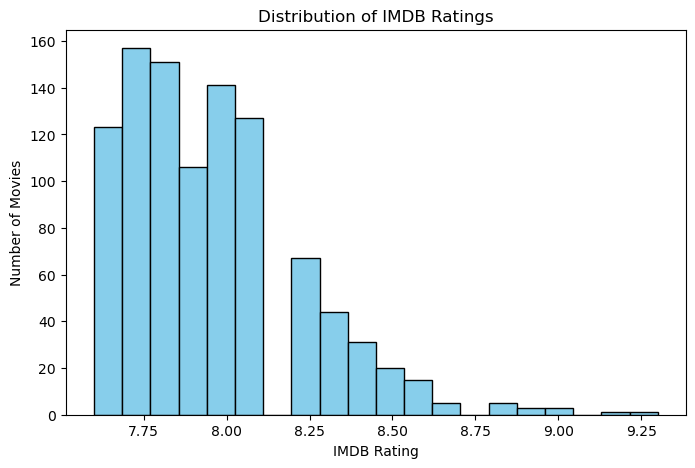

In [198]:
plt.figure(figsize=(8, 5))
plt.hist(df['IMDB_Rating'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of IMDB Ratings')
plt.xlabel('IMDB Rating')
plt.ylabel('Number of Movies')
plt.show()

### **Question 22**
(Visualization) Top 10 Directors aur unki total movies ka ek attractive Bar Chart banayein.

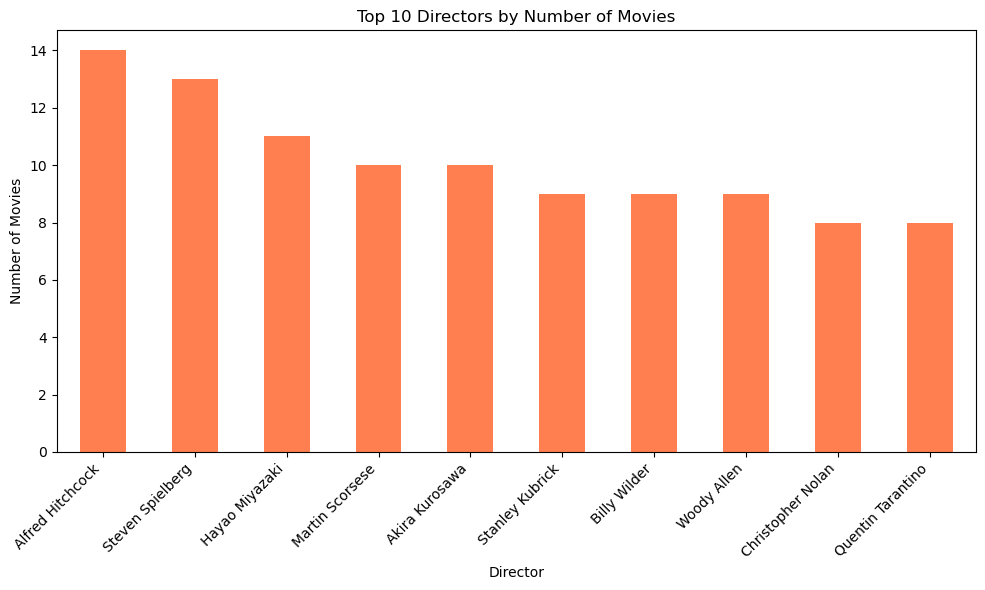

In [205]:
top_directors = df['Director'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_directors.plot(kind='bar', color='coral')
plt.title('Top 10 Directors by Number of Movies')
plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Question 23**
(Visualization) IMDB_Rating aur Gross revenue ke darmiyan ek Scatter Plot banayein taake dono ka relation dikhe.

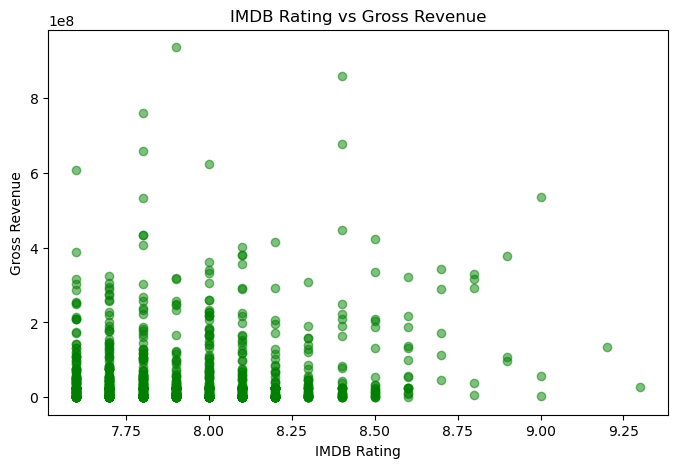

In [214]:
plt.figure(figsize=(8, 5))
plt.scatter(df['IMDB_Rating'], df['Gross'], alpha=0.5, color='green')
plt.title('IMDB Rating vs Gross Revenue')
plt.xlabel('IMDB Rating')
plt.ylabel('Gross Revenue')
plt.show()

### **Question 24**
(Visualization) Genres ka count dekhne ke liye top 5 genres ka ek clean Pie Chart banayein.

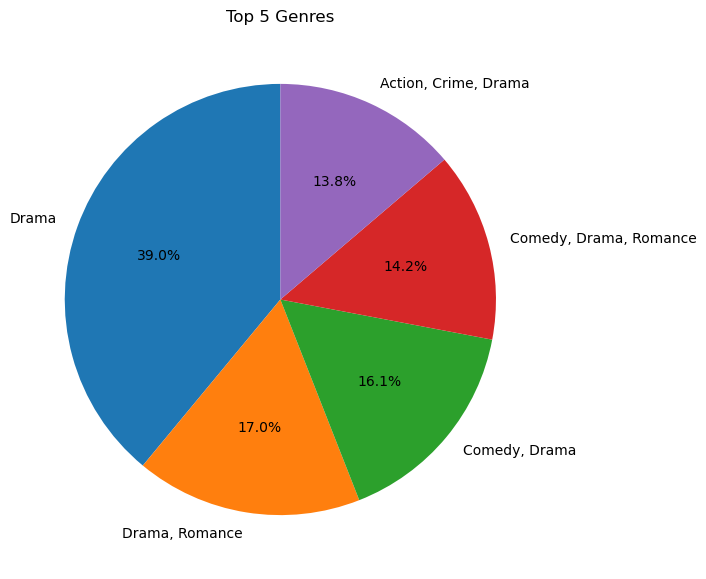

In [221]:
top_5_genres = df['Genre'].value_counts().head(5)

plt.figure(figsize=(7, 7))
plt.pie(top_5_genres, labels=top_5_genres.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 5 Genres')
plt.show()

### **Question 25**
(Visualization) Meta_score ka distribution aur outliers check karne ke liye ek Box Plot banayein.

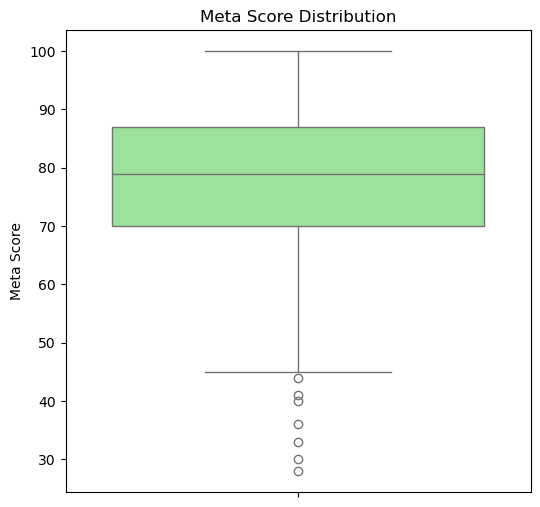

In [228]:
plt.figure(figsize=(6, 6))
sns.boxplot(y=df['Meta_score'], color='lightgreen')
plt.title('Meta Score Distribution')
plt.ylabel('Meta Score')
plt.show()

### **Question 26**
(Visualization) Dataset mein 'Certificate' wise average 'Gross' kamai ka ek Bar Plot banayein.

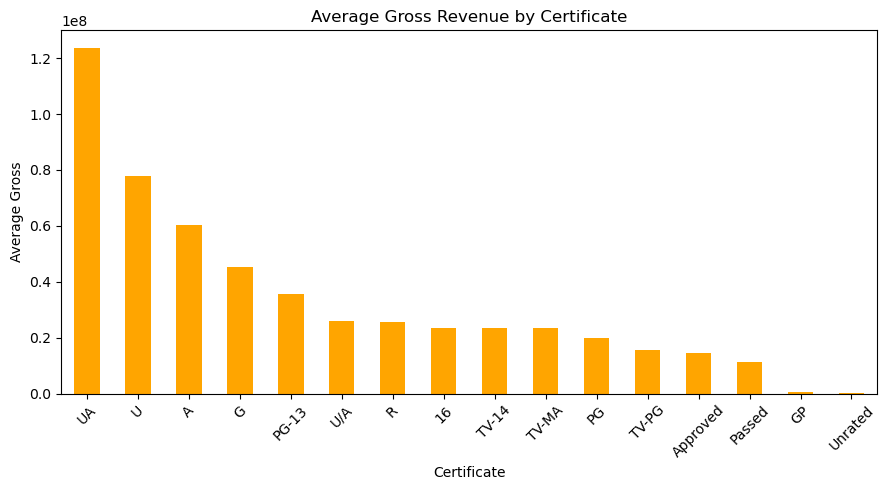

In [239]:
avg_gross_by_cert = df.groupby('Certificate')['Gross'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
avg_gross_by_cert.plot(kind='bar', color='orange')
plt.title('Average Gross Revenue by Certificate')
plt.xlabel('Certificate')
plt.ylabel('Average Gross')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **Question 27**
(Visualization) Har saal (Released_Year) kitni movies release hueen, iska ek Line Plot banayein.

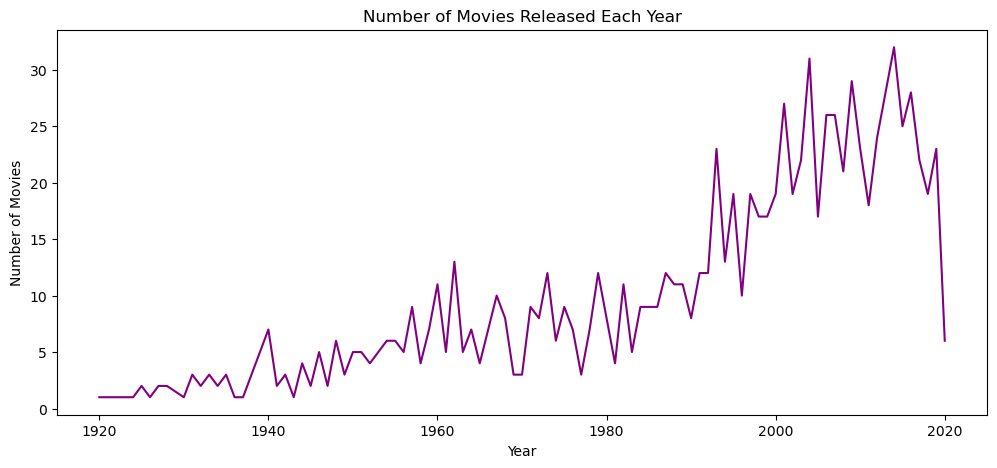

In [258]:
movies_per_year = df['Released_Year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
movies_per_year.plot(kind='line', color='purple')
plt.title('Number of Movies Released Each Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()

### **Question 28**
(Visualization) 'No_of_Votes' ke mutabiq top 5 highest voted movies ka ek Horizontal Bar Chart banayein.

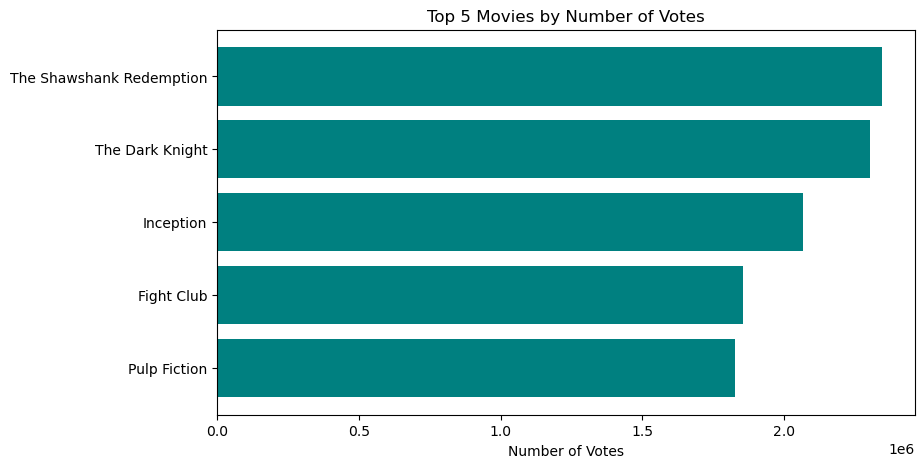

In [267]:
top_5_voted = df.sort_values(by='No_of_Votes', ascending=False).head(5)

plt.figure(figsize=(9, 5))
plt.barh(top_5_voted['Series_Title'], top_5_voted['No_of_Votes'], color='teal')
plt.title('Top 5 Movies by Number of Votes')
plt.xlabel('Number of Votes')
plt.gca().invert_yaxis()
plt.show()

### **Question 29**
Har movie ke 'Genre' column ko split karke check karein ki total unique genres pure dataset mein kitne hain.

In [279]:
all_genres = df['Genre'].str.split(', ')

unique_genres = set()
for genre_list in all_genres:
    for genre in genre_list:
        unique_genres.add(genre)

print("Total unique genres:", len(unique_genres))
print(unique_genres)

Total unique genres: 21
{'Sci-Fi', 'Western', 'Fantasy', 'Thriller', 'Drama', 'Biography', 'Animation', 'Film-Noir', 'War', 'Sport', 'Musical', 'Music', 'Adventure', 'History', 'Comedy', 'Family', 'Horror', 'Mystery', 'Crime', 'Action', 'Romance'}


### **Question 30**
Dataset ko poora clean karne ke baad safely ek nayi csv file 'cleaned_movies.csv' ke naam se save karein.

In [287]:
df.to_csv('cleaned_movies.csv', index=False)
print("Cleaned dataset saved as 'cleaned_movies.csv'")

Cleaned dataset saved as 'cleaned_movies.csv'


### **Question 31**
Kaunsi movies hain jinki 'IMDB_Rating' 8.5 se zyada hai AUR unka 'Gross' revenue 100 million (100,000,000) se zyada hai? (Dual condition filter)

In [296]:
high_rating_high_gross = df[(df['IMDB_Rating'] > 8.5) & (df['Gross'] > 100000000)]
high_rating_high_gross[['Series_Title', 'IMDB_Rating', 'Gross']]

,Series_Title,IMDB_Rating,Gross
1,The Godfather,9.2,134966411.0
2,The Dark Knight,9.0,534858444.0
5,The Lord of the Rings: The Return of the King,8.9,377845905.0
6,Pulp Fiction,8.9,107928762.0
8,Inception,8.8,292576195.0
10,The Lord of the Rings: The Fellowship of the Ring,8.8,315544750.0
11,Forrest Gump,8.8,330252182.0
13,The Lord of the Rings: The Two Towers,8.7,342551365.0
14,The Matrix,8.7,171479930.0
16,Star Wars: Episode V - The Empire Strikes Back,8.7,290475067.0


### **Question 32**
Director 'Christopher Nolan' ki un movies ke naam aur release year nikalein jinka 'Runtime' 140 minutes se zyada hai.

In [305]:
nolan_long_movies = df[(df['Director'] == 'Christopher Nolan') & (df['Runtime'] > 140)]
nolan_long_movies[['Series_Title', 'Released_Year', 'Runtime']]

,Series_Title,Released_Year,Runtime
2,The Dark Knight,2008.0,152
8,Inception,2010.0,148
21,Interstellar,2014.0,169
63,The Dark Knight Rises,2012.0,164


### **Question 33**
Aise actors (Star1) ki list nikalein jinhone 'Action' ya 'Sci-Fi' genre mein kaam kiya hai AUR unki movies ki 'IMDB_Rating' kam az kam 8.0 hai.

In [321]:
action_scifi_actors = df[
    (df['Genre'].str.contains('Action', na=False) | df['Genre'].str.contains('Sci-Fi', na=False))
    & (df['IMDB_Rating'] >= 8.0)
]

unique_actors = action_scifi_actors['Star1'].unique()
print("Total such actors:", len(unique_actors))
print(unique_actors)

Total such actors: 72
['Christian Bale' 'Elijah Wood' 'Leonardo DiCaprio' 'Lilly Wachowski'
 'Mark Hamill' 'Matthew McConaughey' 'Tatsuya Nakadai' 'Toshirô Mifune'
 'Russell Crowe' 'Jean Reno' 'Arnold Schwarzenegger' 'Michael J. Fox'
 'Pushkar' 'Aamir Khan' 'Peter Ramsey' 'Joe Russo' 'Choi Min-sik'
 'Yôji Matsuda' 'Harrison Ford' 'Sigourney Weaver' 'Jim Carrey'
 'Malcolm McDowell' 'Keir Dullea' 'Brigitte Helm' 'Vicky Kaushal' 'Yash'
 'Prabhas' 'Manoj Bajpayee' 'Irrfan Khan' 'Tom Hardy' 'Hugo Weaving'
 'Akshay Kumar' 'Jason Flemyng' 'Bruce Willis' 'Alisa Freyndlikh'
 'Sanjeev Kumar' 'Buster Keaton' 'Shahid Kapoor' 'Hugh Jackman'
 'Daniel Brühl' 'Matt Damon' 'Anupam Kher' 'Chris Sanders' 'Jang Dong-Gun'
 'Uma Thurman' 'Kazuya Tsurumaki' 'Sam Neill' 'Kurt Russell'
 'Natalya Bondarchuk' 'James Cagney' 'Salman Khan' 'Iko Uwais'
 'Chris Pratt' 'Joaquin Phoenix' 'Wagner Moura' 'Ryan Reynolds'
 'Donnie Yen' 'Erdem Can' 'Robert Downey Jr.' 'Cem Yilmaz' 'Daniel Craig'
 'Alan Mak' 'Johnny Depp' '

### **Question 34**
Year 2010 se 2020 ke darmiyan release hone wali un movies ka data filter karein jinko Certificate 'UA' ya 'A' mila hai.

In [329]:
filtered_movies = df[
    (df['Released_Year'] >= 2010) & (df['Released_Year'] <= 2020)
    & (df['Certificate'].isin(['UA', 'A']))
]

filtered_movies[['Series_Title', 'Released_Year', 'Certificate']]

,Series_Title,Released_Year,Certificate
8,Inception,2010.0,UA
19,Gisaengchung,2019.0,A
21,Interstellar,2014.0,UA
33,Joker,2019.0,A
34,Whiplash,2014.0,A
...,...,...,...
898,Dawn of the Planet of the Apes,2014.0,UA
900,Serbuan maut,2011.0,A
901,End of Watch,2012.0,A
903,A Star Is Born,2018.0,UA


### **Question 35**
Dataset mein 'Meta_score' 90 se zyada aur 'IMDB_Rating' 8.5 se kam wali unique movies kaunsi hain?

In [339]:
special_movies = df[(df['Meta_score'] > 90) & (df['IMDB_Rating'] < 8.5)]
special_movies[['Series_Title', 'Meta_score', 'IMDB_Rating']].drop_duplicates()

,Series_Title,Meta_score,IMDB_Rating
66,WALL·E,95.0,8.4
74,Apocalypse Now,94.0,8.4
78,Dr. Strangelove or: How I Learned to Stop Worr...,97.0,8.4
81,Rear Window,100.0,8.4
89,Jodaeiye Nader az Simin,95.0,8.3
...,...,...,...
875,Fantasia,96.0,7.7
881,The Florida Project,92.0,7.6
895,Leviafan,92.0,7.6
994,A Hard Day's Night,96.0,7.6


### **Question 36**
(Visualization) 'Drama' aur 'Action' genres ki movies ke 'Gross' revenue ko compare karne ke liye ek Grouped Box Plot ya Violin Plot banayein.

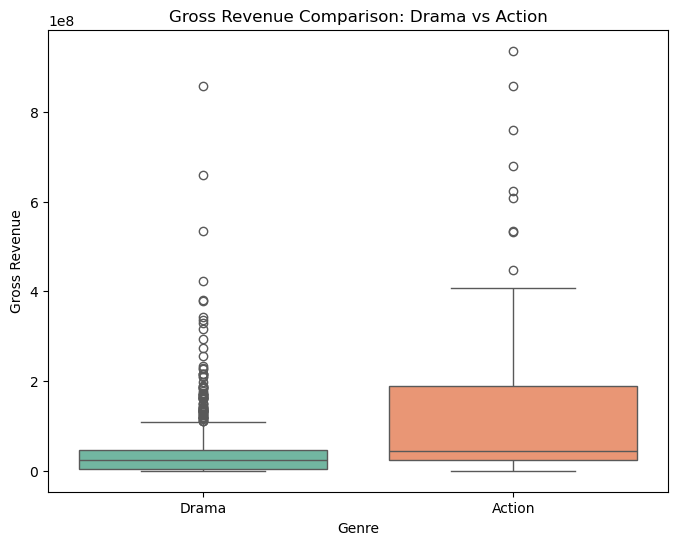

In [362]:
drama_gross = df[df['Genre'].str.contains('Drama', na=False)].copy()
drama_gross['Genre_Group'] = 'Drama'

action_gross = df[df['Genre'].str.contains('Action', na=False)].copy()
action_gross['Genre_Group'] = 'Action'

combined = pd.concat([drama_gross, action_gross])

plt.figure(figsize=(8, 6))
sns.boxplot(x='Genre_Group', y='Gross', data=combined, hue='Genre_Group', palette='Set2', legend=False)
plt.title('Gross Revenue Comparison: Drama vs Action')
plt.xlabel('Genre')
plt.ylabel('Gross Revenue')
plt.show()

### **Question 37**
Har Director ki un movies ka count maloom karein jinhone 'No_of_Votes' 500,000 (5 lakh) se zyada hasil kiye hain.

In [380]:
popular_movies = df[df['No_of_Votes'] > 500000]
director_counts = popular_movies['Director'].value_counts()

director_counts

Director
Christopher Nolan    8
Quentin Tarantino    8
Steven Spielberg     8
Peter Jackson        5
David Fincher        5
                    ..
Richard Marquand     1
Brian De Palma       1
Mel Gibson           1
Gus Van Sant         1
Chris Columbus       1
Name: count, Length: 107, dtype: int64

### **Question 38**
Un movies ke naam aur ratings batayein jinka 'Released_Year' 2000 se pehle ka hai AUR unka 'Gross' unke overall median gross se zyada hai.

In [388]:
median_gross_overall = df['Gross'].median()

old_high_gross_movies = df[(df['Released_Year'] < 2000) & (df['Gross'] > median_gross_overall)]
old_high_gross_movies[['Series_Title', 'IMDB_Rating', 'Gross']]

,Series_Title,IMDB_Rating,Gross
0,The Shawshank Redemption,9.3,28341469.0
1,The Godfather,9.2,134966411.0
3,The Godfather: Part II,9.0,57300000.0
6,Pulp Fiction,8.9,107928762.0
7,Schindler's List,8.9,96898818.0
...,...,...,...
985,Escape from Alcatraz,7.6,43000000.0
987,Midnight Express,7.6,35000000.0
988,Close Encounters of the Third Kind,7.6,132088635.0
992,The Jungle Book,7.6,141843612.0


### **Question 39**
Aisi movies ka data nikalein jahan 'Star1' (Main Actor) aur 'Director' dono bilkul same person hain.

In [397]:
same_person_movies = df[df['Star1'] == df['Director']]
same_person_movies[['Series_Title', 'Director', 'Star1']]

,Series_Title,Director,Star1
26,La vita è bella,Roberto Benigni,Roberto Benigni
51,Modern Times,Charles Chaplin,Charles Chaplin
52,City Lights,Charles Chaplin,Charles Chaplin
83,The Great Dictator,Charles Chaplin,Charles Chaplin
102,Braveheart,Mel Gibson,Mel Gibson
124,Citizen Kane,Orson Welles,Orson Welles
127,The Kid,Charles Chaplin,Charles Chaplin
167,Unforgiven,Clint Eastwood,Clint Eastwood
193,The Gold Rush,Charles Chaplin,Charles Chaplin
194,Sherlock Jr.,Buster Keaton,Buster Keaton


### **Question 40**
(Visualization) Top 5 highest rated movies aur unke 'Meta_score' vs 'IMDB_Rating' (scaled to 100) ka ek Side-by-Side Comparison Bar Chart banayein.

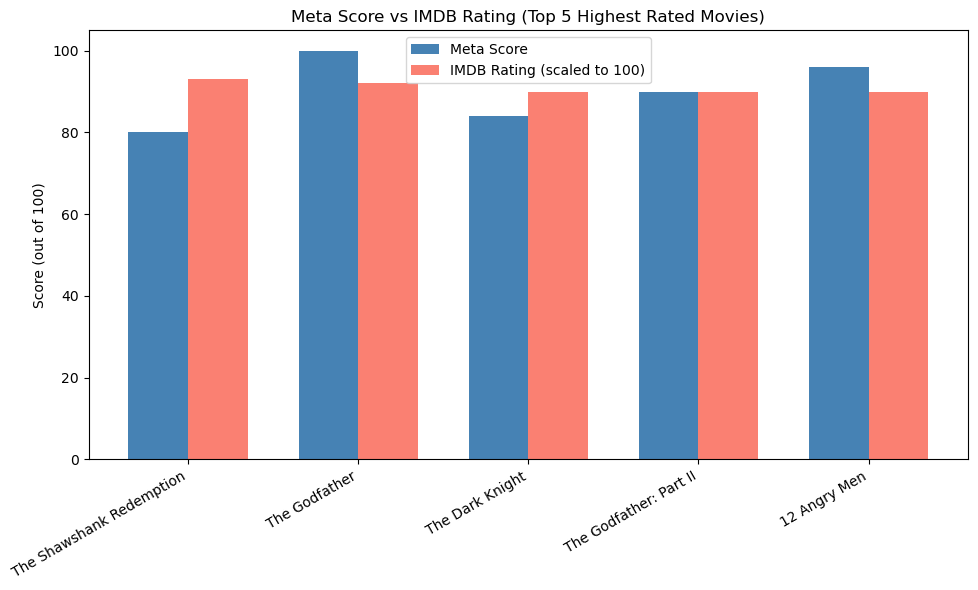

In [419]:
top_5_rated = df.sort_values(by='IMDB_Rating', ascending=False).head(5).copy()
top_5_rated['IMDB_Rating_Scaled'] = top_5_rated['IMDB_Rating'] * 10

x = range(len(top_5_rated))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar([i - width/2 for i in x], top_5_rated['Meta_score'], width=width, label='Meta Score', color='steelblue')
plt.bar([i + width/2 for i in x], top_5_rated['IMDB_Rating_Scaled'], width=width, label='IMDB Rating (scaled to 100)', color='salmon')

plt.xticks(list(x), top_5_rated['Series_Title'], rotation=30, ha='right')
plt.title('Meta Score vs IMDB Rating (Top 5 Highest Rated Movies)')
plt.ylabel('Score (out of 100)')
plt.legend()
plt.tight_layout()
plt.show()